In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

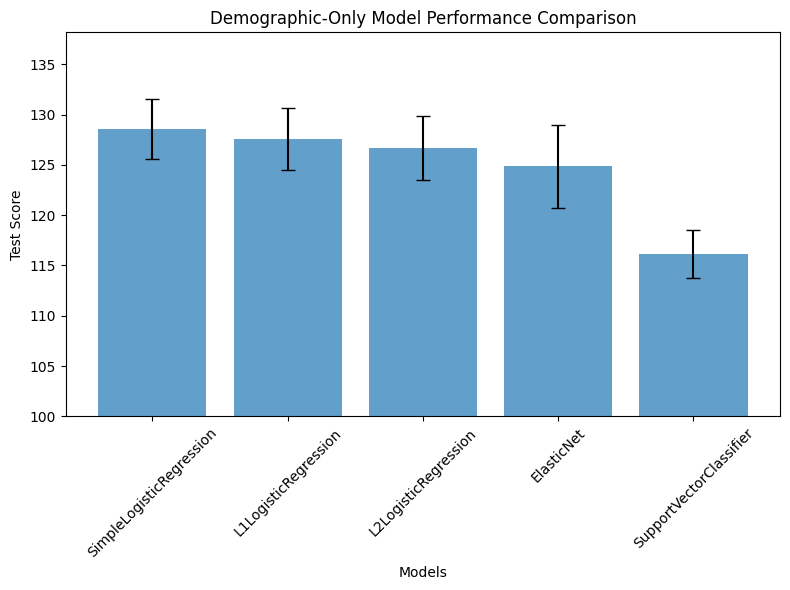

In [11]:
# DEMOGRAPHIC-ONLY PLOT
# load data
df = pd.read_csv('../results/barplot_data/barplot_demographics_only/channel_sweep_test_scores_by_model.csv')

test_cols = [col for col in df.columns if col.endswith('_test_score')]
models = [col.replace('_test_score', '') for col in test_cols]

mean_scores = df[test_cols].mean().values
std_scores = df[test_cols].std().values

n = df['random_state'].nunique()
stderr_scores = std_scores / np.sqrt(n)

# reorder
desired_order = ['SimpleLogisticRegression', 'L1LogisticRegression', 'L2LogisticRegression', 'ElasticNet', 'SupportVectorClassifier']
order_map = {m: i for i, m in enumerate(models)}
idx = [order_map[m] for m in desired_order]

models, mean_scores, stderr_scores = (
    [models[i] for i in idx],
    mean_scores[idx],
    stderr_scores[idx]
)

# ---- plotting ----
plt.figure(figsize=(8, 6))
bars = plt.bar(models, mean_scores, yerr=stderr_scores, capsize=5, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Test Score')
plt.title('Demographic-Only Model Performance Comparison')
plt.xticks(rotation=45)
plt.ylim(100)
plt.tight_layout()
plt.show()

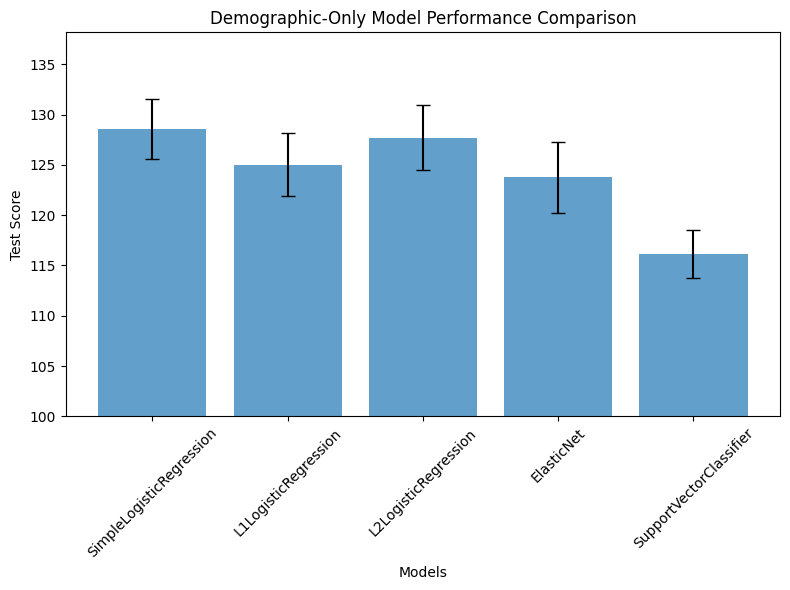

In [4]:
# DEMOGRAPHIC-ONLY PLOT
# load data
df = pd.read_csv('../results/barplot_data/demographics_only_1/scores.csv')

test_cols = [col for col in df.columns if col.endswith('_test_score')]
models = [col.replace('_test_score', '') for col in test_cols]

mean_scores = df[test_cols].mean().values
std_scores = df[test_cols].std().values

n = df['random_state'].nunique()
stderr_scores = std_scores / np.sqrt(n)

# reorder
desired_order = ['SimpleLogisticRegression', 'L1LogisticRegression', 'L2LogisticRegression', 'ElasticNet', 'SupportVectorClassifier']
order_map = {m: i for i, m in enumerate(models)}
idx = [order_map[m] for m in desired_order]

models, mean_scores, stderr_scores = (
    [models[i] for i in idx],
    mean_scores[idx],
    stderr_scores[idx]
)

# ---- plotting ----
plt.figure(figsize=(8, 6))
bars = plt.bar(models, mean_scores, yerr=stderr_scores, capsize=5, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Test Score')
plt.title('Demographic-Only Model Performance Comparison')
plt.xticks(rotation=45)
plt.ylim(100)
plt.tight_layout()
plt.show()

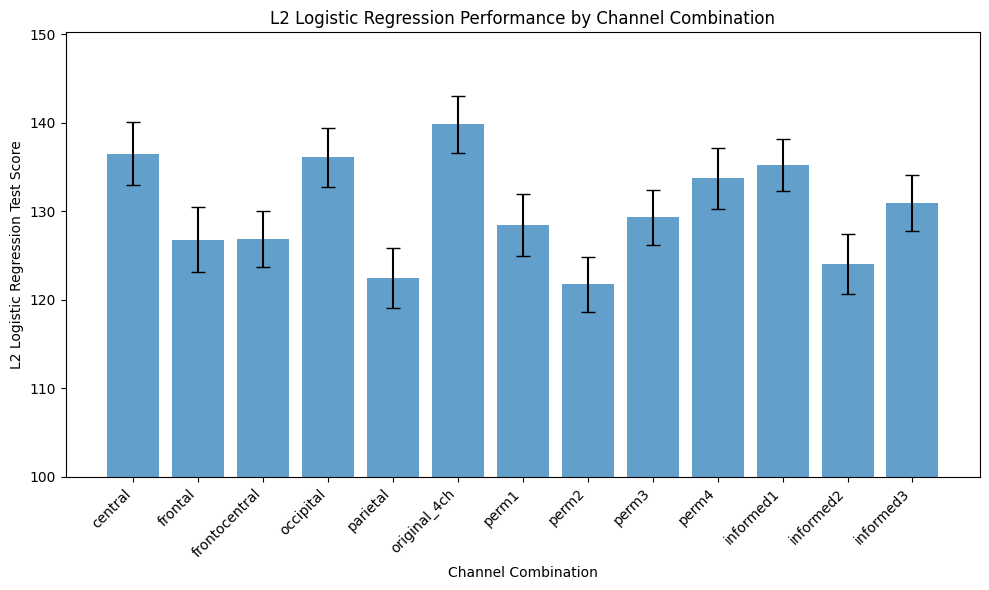

In [7]:
# CHANNEL COMPARISON
# load data
df = pd.read_csv('../results/barplot_data/channel_comparison/channel_sweep_test_scores_by_model.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('combo_name')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# reorder
desired_order = ['central', 'frontal', 'frontocentral', 'occipital', 'parietal', 'original_4ch', 'perm1', 'perm2', 'perm3', 'perm4', 'informed1', 'informed2', 'informed3']
mean_scores = mean_scores.reindex(desired_order)
stderr_scores = stderr_scores.reindex(desired_order)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Channel Combination')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Channel Combination')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

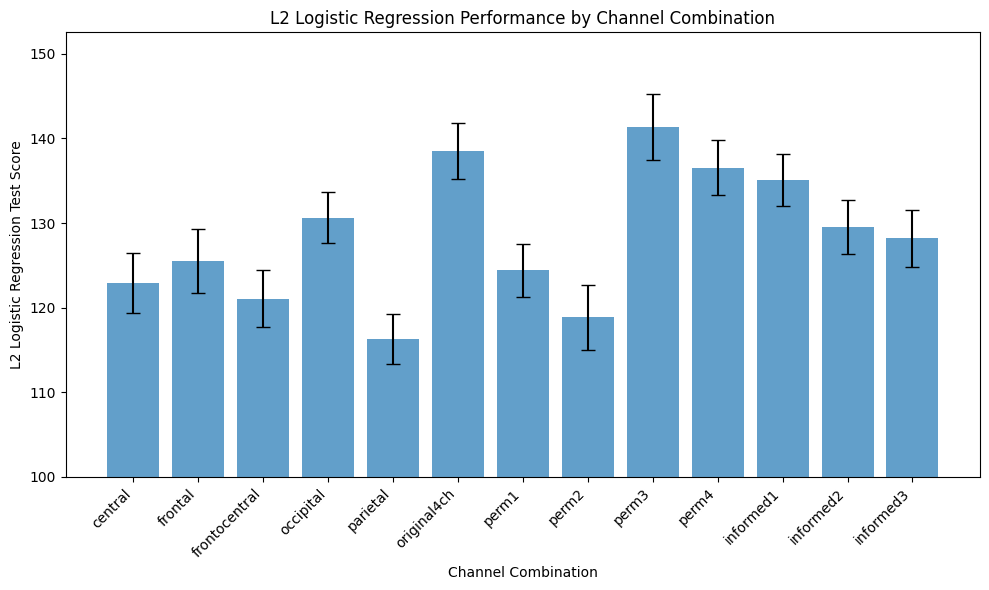

In [6]:
# CHANNEL COMPARISON
# load data
df = pd.read_csv('../results/barplot_data/channel_comparison_1/scores.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('combo_name')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# reorder
desired_order = ['central', 'frontal', 'frontocentral', 'occipital', 'parietal', 'original4ch', 'perm1', 'perm2', 'perm3', 'perm4', 'informed1', 'informed2', 'informed3']
mean_scores = mean_scores.reindex(desired_order)
stderr_scores = stderr_scores.reindex(desired_order)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Channel Combination')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Channel Combination')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

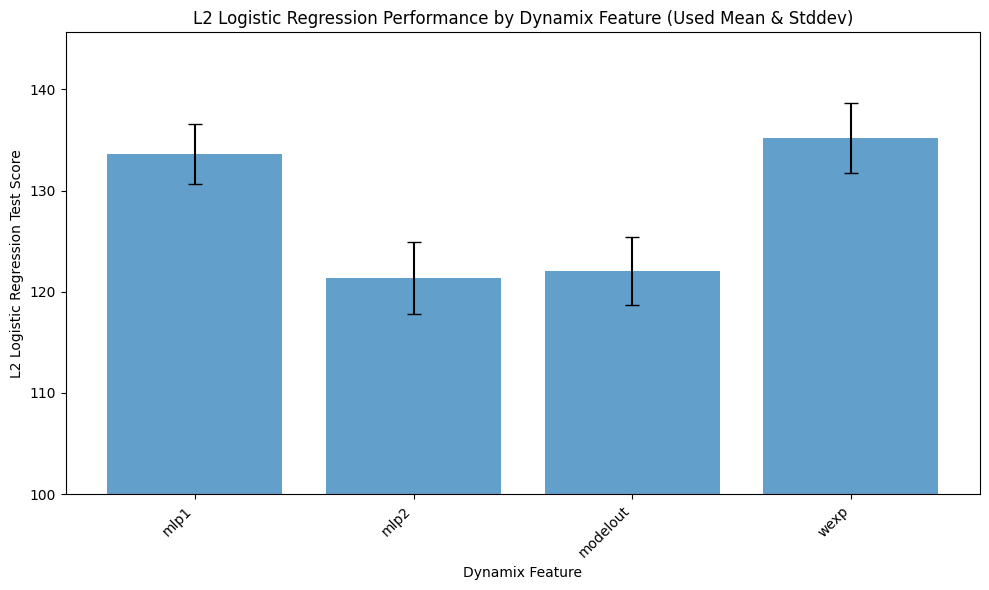

In [8]:
# DYNAMIX FEATURES COMPARISON
# load data
df = pd.read_csv('../results/barplot_data/dynamix_components/channel_sweep_test_scores_by_model.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from dynamix_wexp_std_mean --> wexp
def clean_name(name):
    name = name.replace('dynamix_', '')
    return name.split('_')[0]

mean_scores.index = mean_scores.index.map(clean_name)
stderr_scores.index = stderr_scores.index.map(clean_name)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Dynamix Feature')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Dynamix Feature (Used Mean & Stddev)')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

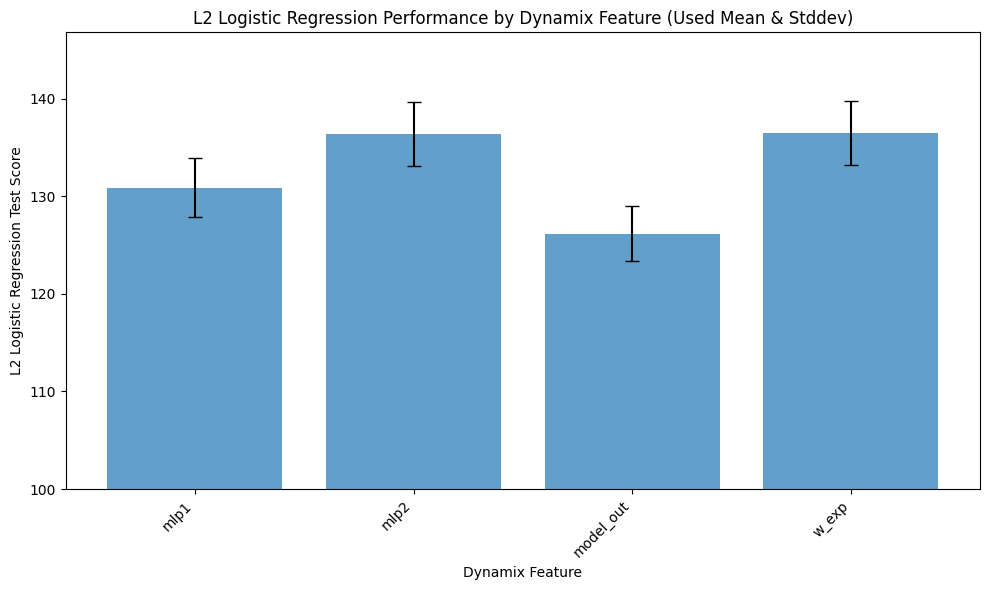

In [21]:
# DYNAMIX FEATURES COMPARISON
# load data
df = pd.read_csv('../results/barplot_data/dynamix_components_1/scores.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from dynamix_wexp_std_mean --> wexp
def clean_name(col):
    match = re.match(r"dynamix_(.*)_std", col)
    if match:
        return match.group(1)
    return col

mean_scores.index = mean_scores.index.map(clean_name)
stderr_scores.index = stderr_scores.index.map(clean_name)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Dynamix Feature')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Dynamix Feature (Used Mean & Stddev)')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

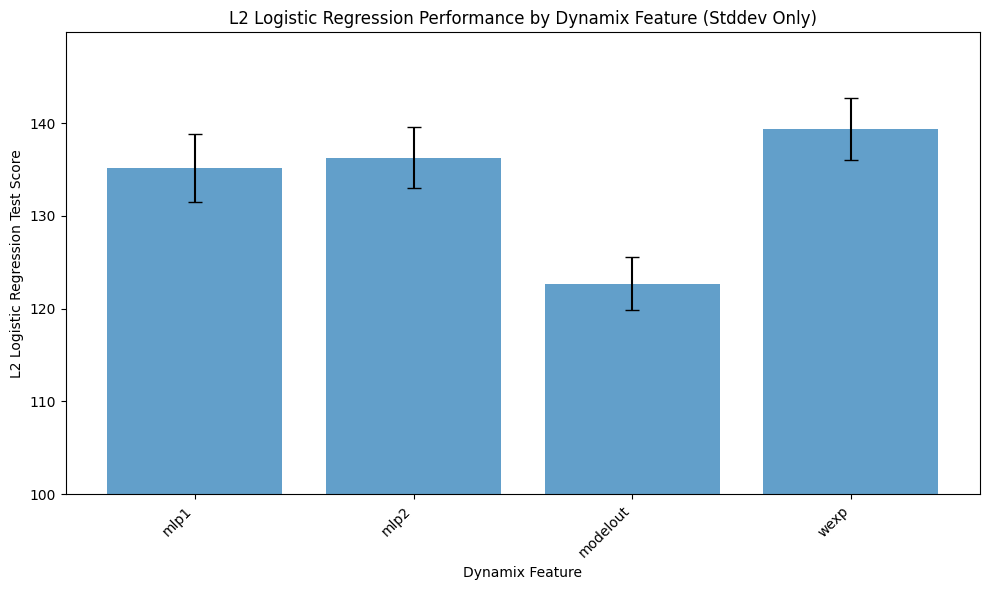

In [15]:
# DYNAMIX FEATURES STDDEV COMPARISON
# load data
df = pd.read_csv('../results/barplot_data/dynamix_components_std/channel_sweep_test_scores_by_model.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from dynamix_wexp_std_mean --> wexp
def clean_name(name):
    name = name.replace('dynamix_', '')
    return name.split('_')[0]

mean_scores.index = mean_scores.index.map(clean_name)
stderr_scores.index = stderr_scores.index.map(clean_name)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Dynamix Feature')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Dynamix Feature (Stddev Only)')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

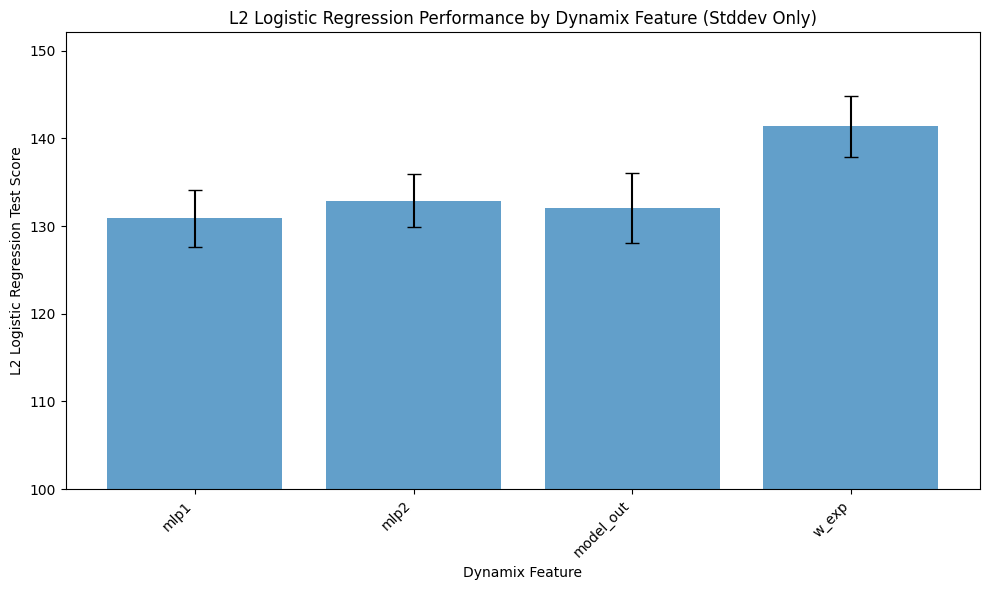

In [20]:
# DYNAMIX FEATURES STDDEV COMPARISON
# load data
df = pd.read_csv('../results/barplot_data/dynamix_components_std_1/scores.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from dynamix_wexp_std_mean --> wexp
def clean_name(col):
    match = re.match(r"dynamix_(.*)_std", col)
    if match:
        return match.group(1)
    return col

mean_scores.index = mean_scores.index.map(clean_name)
stderr_scores.index = stderr_scores.index.map(clean_name)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Dynamix Feature')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Dynamix Feature (Stddev Only)')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

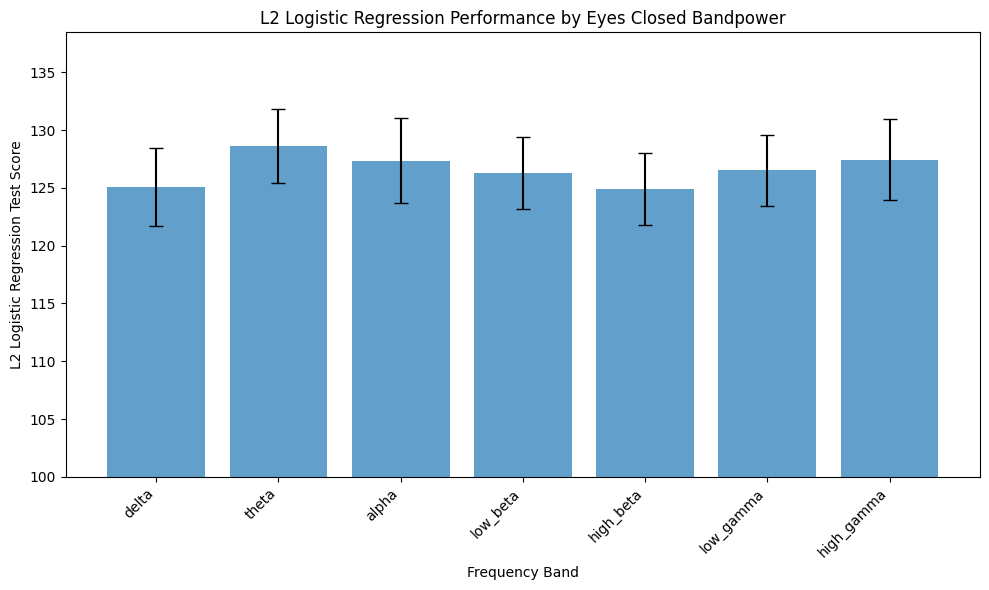

In [8]:
# BANDPOWER
# load data
df = pd.read_csv('../results/barplot_data/bandpower_comparison/channel_sweep_test_scores_by_model.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from bandpower_ec_alpha --> alpha
def clean_bp_name(name):
    name = name.replace('bandpower_ec_', '')
    return name

mean_scores.index = mean_scores.index.map(clean_bp_name)
stderr_scores.index = stderr_scores.index.map(clean_bp_name)

# reorder
desired_order = ['delta', 'theta', 'alpha', 'low_beta', 'high_beta', 'low_gamma', 'high_gamma']
mean_scores = mean_scores.reindex(desired_order)
stderr_scores = stderr_scores.reindex(desired_order)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Frequency Band')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Eyes Closed Bandpower')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

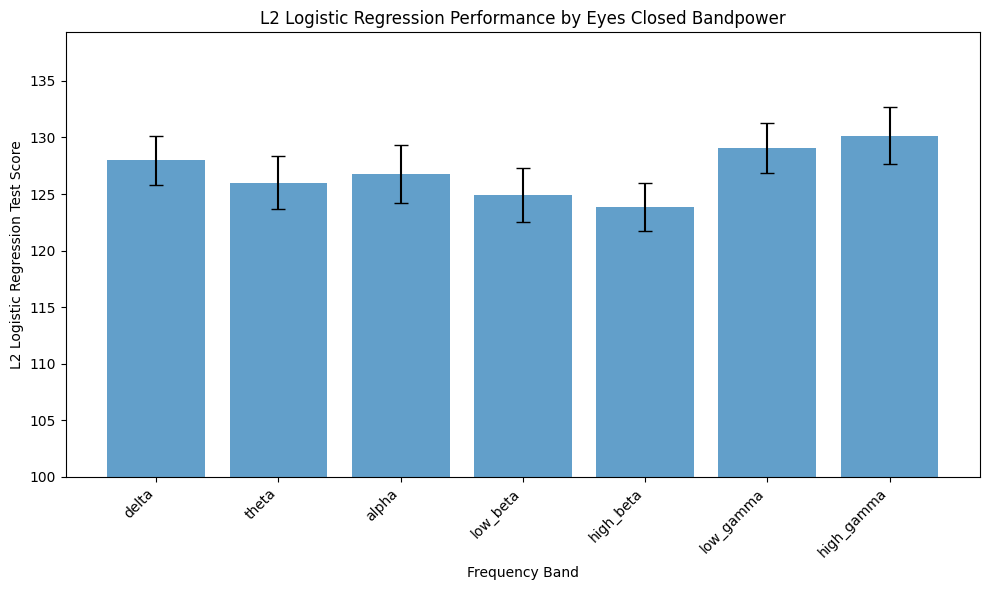

In [12]:
# BANDPOWER
# load data
df = pd.read_csv('../results/barplot_data/bandpower_comparison_1/scores.csv')

col = 'L2LogisticRegression_test_score'

# group by combo_name
grouped = df.groupby('feature_subset')[col]

mean_scores = grouped.mean()
std_scores = grouped.std()
n = grouped.count()
stderr_scores = std_scores / np.sqrt(n)

# replace names from bandpower_ec_alpha --> alpha
def clean_bp_name(name):
    name = name.replace('bandpower_ec_', '')
    return name

mean_scores.index = mean_scores.index.map(clean_bp_name)
stderr_scores.index = stderr_scores.index.map(clean_bp_name)

# reorder
desired_order = ['delta', 'theta', 'alpha', 'low_beta', 'high_beta', 'low_gamma', 'high_gamma']
mean_scores = mean_scores.reindex(desired_order)
stderr_scores = stderr_scores.reindex(desired_order)

# ---- plotting ----
plt.figure(figsize=(10, 6))

plt.bar(mean_scores.index, mean_scores.values, yerr=stderr_scores.values, capsize=5, alpha=0.7)

plt.xlabel('Frequency Band')
plt.ylabel('L2 Logistic Regression Test Score')
plt.title('L2 Logistic Regression Performance by Eyes Closed Bandpower')

plt.xticks(rotation=45, ha='right')
plt.ylim(100)
plt.tight_layout()
plt.show()

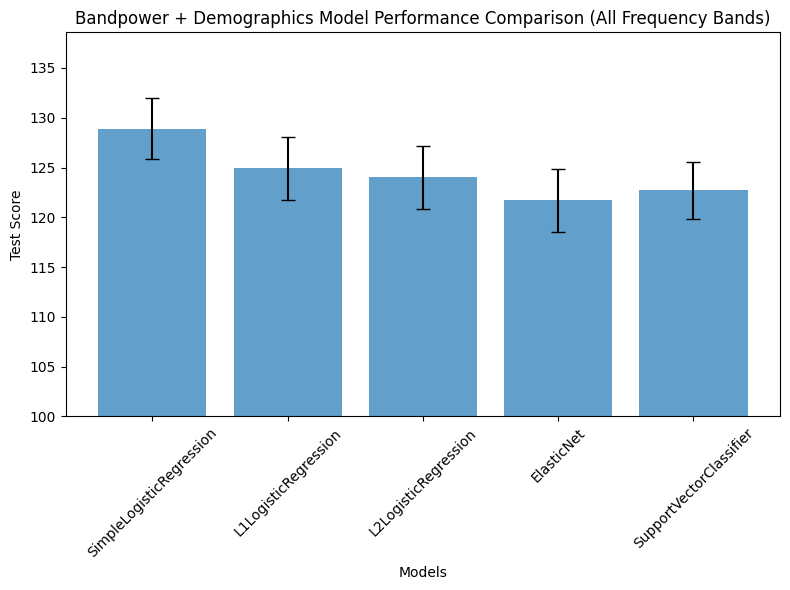

In [13]:
# BANDPOWER ALL (all bandpowers in one feature mat)
# load data
df = pd.read_csv('../results/barplot_data/bandpower_comparison_all/scores.csv')

test_cols = [col for col in df.columns if col.endswith('_test_score')]
models = [col.replace('_test_score', '') for col in test_cols]

mean_scores = df[test_cols].mean().values
std_scores = df[test_cols].std().values

n = df['random_state'].nunique()
stderr_scores = std_scores / np.sqrt(n)

# reorder
desired_order = ['SimpleLogisticRegression', 'L1LogisticRegression', 'L2LogisticRegression', 'ElasticNet', 'SupportVectorClassifier']
order_map = {m: i for i, m in enumerate(models)}
idx = [order_map[m] for m in desired_order]

models, mean_scores, stderr_scores = (
    [models[i] for i in idx],
    mean_scores[idx],
    stderr_scores[idx]
)

# ---- plotting ----
plt.figure(figsize=(8, 6))
bars = plt.bar(models, mean_scores, yerr=stderr_scores, capsize=5, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Test Score')
plt.title('Bandpower + Demographics Model Performance Comparison (All Frequency Bands)')
plt.xticks(rotation=45)
plt.ylim(100)
plt.tight_layout()
plt.show()

In [30]:
# # ---two-way comparison---
# model1 = 'remitter_mdd_bp_nppv'
# model2 = 'remitter_mdd_dyna_all_nppv'
# dataset1 = 'Demographic + Bandpower'
# dataset2 = 'Demographic + Dynamix Features'
# response_var_cap = 'Remitter'
# eval_metric = 'nPPV'

# ---three-way comparison---
model1 = 'remitter_mdd_nppv'
model2 = 'remitter_mdd_bp_nppv'
model3 = 'remitter_mdd_dyna_all_nppv'
dataset1 = 'Demographic Only'
dataset2 = 'Demographic + Bandpower'
dataset3 = 'Demographic + Dynamix Features'
response_var_cap = 'Remitter'
eval_metric = 'nPPV'

In [31]:
# # ---two-way comparison---
df1 = pd.read_csv(f'../../results/summary/{model1}_summary.csv')
df2 = pd.read_csv(f'../../results/summary/{model2}_summary.csv')

# combine the DataFrames
combined_df = pd.concat([df1, df2], ignore_index=True)

datasets_list = [df1, df2]
dataset_labels = [dataset1, dataset2]
models = df1.columns.values

# # ---three-way comparison---
# df1 = pd.read_csv(f'../../results/summary/{model1}_summary.csv')
# df2 = pd.read_csv(f'../../results/summary/{model2}_summary.csv')
# df3 = pd.read_csv(f'../../results/summary/{model3}_summary.csv')

# # combine the DataFrames
# combined_df = pd.concat([df1, df2, df3], ignore_index=True)

# datasets_list = [df1, df2, df3]
# dataset_labels = [dataset1, dataset2, dataset3]
# models = df1.columns.values

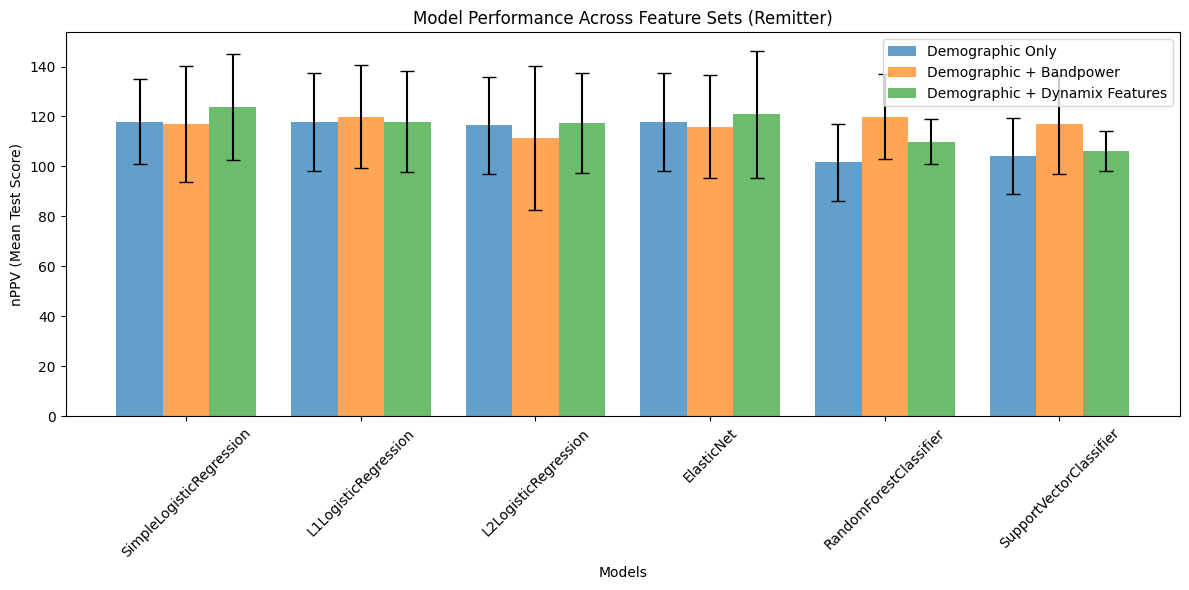

In [32]:
num_datasets = len(datasets_list)
x = np.arange(len(models))
width = 0.8 / num_datasets  # total width split evenly among groups

fig, ax = plt.subplots(figsize=(12,6))

# loop over datasets
for i, (df, label) in enumerate(zip(datasets_list, dataset_labels)):
    means = df.iloc[1].values  # row 1 = mean
    stds = df.iloc[2].values   # row 2 = std
    ax.bar(x + (i - num_datasets/2 + 0.5)*width, means, width, yerr=stds, capsize=5, alpha=0.7, label=label)
    
# labels and title
ax.set_xlabel('Models')
ax.set_ylabel(f'{eval_metric} (Mean Test Score)')
ax.set_title(f'Model Performance Across Feature Sets ({response_var_cap})')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)
# ax.set_ylim(0, 1)

ax.legend()
plt.tight_layout()
plt.show()